# mmFall Fall Detection — Representation 2: Orthogonal Projections (ResNet-18)

This notebook processes the **Representation 2 (Dual Orthogonal 2D Spatial Projections)** format for mmWave radar fall detection, training a **ResNet-18** spatial model in PyTorch as specified in the research plan (*'Comparing mmWave Radar Data Formats for Fall Detection' by Joey van der Poel*).

---

### 📡 Representation & Model Specifications:
- **Representation Format**: Dual 2D Spatial Grid Image $I \in \mathbb{R}^{3 \times 64 \times 64}$.
- **Channels**: 3 Channels ($XZ$ Side Elevation Grid, $XY$ Ground Plan Grid, and Velocity-Weighted Projection Grid).
- **Target Posture**: Captures vertical height drop ($Z$-axis elevation) and horizontal body area expansion during collapse.
- **Model Backbone**: PyTorch **ResNet-18** Spatial Feature Extractor.


In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
torch.manual_seed(42)
np.random.seed(42)

# Load Preprocessed Representation 2 Tensors
preproc_dir = Path("datasets/preprocessed")
if not preproc_dir.exists():
    preproc_dir = Path("../datasets/preprocessed")
if not preproc_dir.exists():
    preproc_dir = Path("../../datasets/preprocessed")
X_rep2 = np.load(preproc_dir / "X_rep2_projections.npy") # Shape: (1182, 3, 64, 64)
y_rep2 = np.load(preproc_dir / "y_rep2_projections.npy") # Shape: (1182,)

print(f"Loaded Representation 2 Projections Tensor: {X_rep2.shape}")
print(f"Labels: {np.bincount(y_rep2.astype(int))} (0 = ADL, 1 = Fall)")


Loaded Representation 2 Projections Tensor: (1182, 3, 64, 64)
Labels: [591 591] (0 = ADL, 1 = Fall)


C:\Users\joeyw\AppData\Local\Temp\ipykernel_20348\376830374.py:20: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\joeyw\AppData\Local\Temp\ipykernel_20348\376830374.py:20: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\joeyw\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\joeyw\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


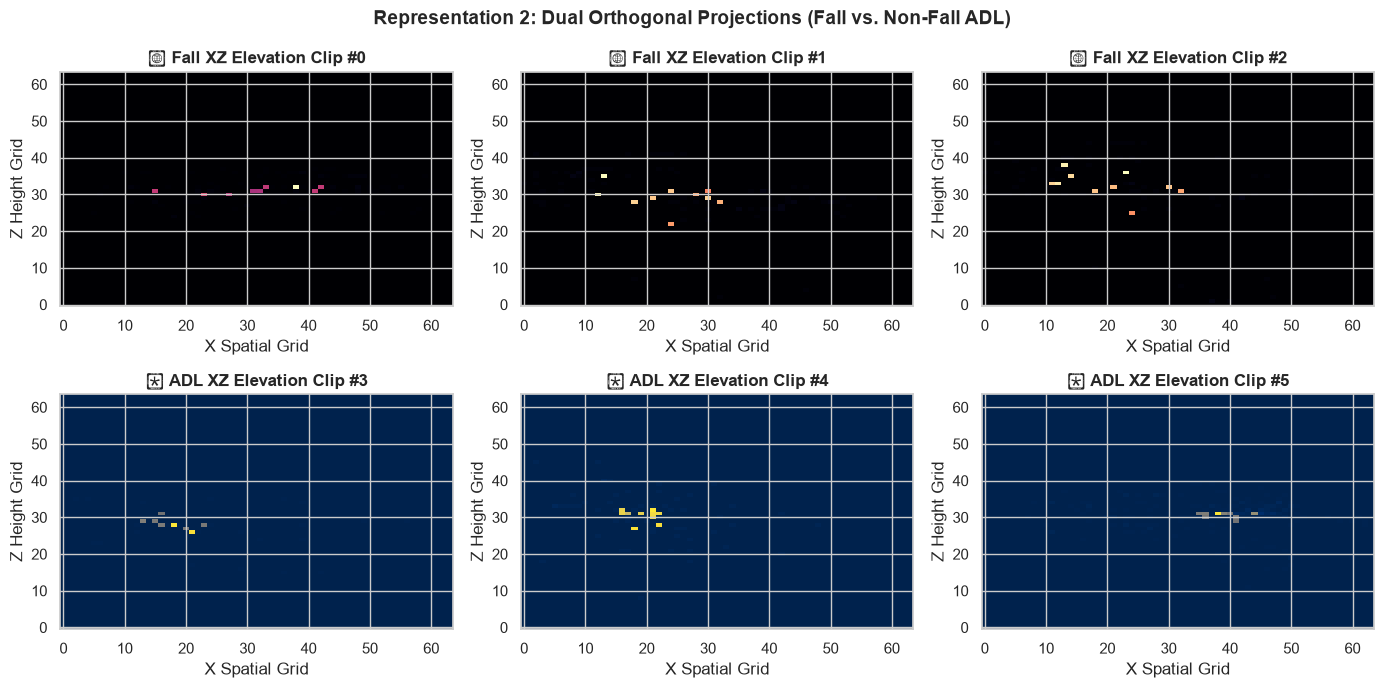

In [2]:
# Visualize Sample Orthogonal Spatial Projections
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fall_indices = np.where(y_rep2 == 1)[0]
adl_indices = np.where(y_rep2 == 0)[0]

for i in range(3):
    idx_f = fall_indices[i]
    idx_a = adl_indices[i]
    axes[0, i].imshow(X_rep2[idx_f, 0], aspect="auto", cmap="magma", origin="lower")
    axes[0, i].set_title(f"🔴 Fall XZ Elevation Clip #{idx_f}", fontweight="bold")
    axes[0, i].set_xlabel("X Spatial Grid")
    axes[0, i].set_ylabel("Z Height Grid")
    
    axes[1, i].imshow(X_rep2[idx_a, 0], aspect="auto", cmap="cividis", origin="lower")
    axes[1, i].set_title(f"🟢 ADL XZ Elevation Clip #{idx_a}", fontweight="bold")
    axes[1, i].set_xlabel("X Spatial Grid")
    axes[1, i].set_ylabel("Z Height Grid")

plt.suptitle("Representation 2: Dual Orthogonal Projections (Fall vs. Non-Fall ADL)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [3]:
# Define ResNet-18 Spatial Model in PyTorch
class ResNet18Projections(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super(ResNet18Projections, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        feat = torch.flatten(self.features(x), 1)
        return self.fc(feat)

# Split Train & Test Sets (80% / 20% Stratified)
X_tr, X_te, y_tr, y_te = train_test_split(X_rep2, y_rep2, test_size=0.2, random_state=42, stratify=y_rep2)
print(f"Train samples: {len(X_tr)}, Test samples: {len(X_te)}")


Train samples: 945, Test samples: 237


In [4]:
# Train ResNet-18 Projections Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet18Projections().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

tr_ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.long))
te_ds = TensorDataset(torch.tensor(X_te, dtype=torch.float32), torch.tensor(y_te, dtype=torch.long))
tr_loader = DataLoader(tr_ds, batch_size=32, shuffle=True)
te_loader = DataLoader(te_ds, batch_size=32, shuffle=False)

epochs = 15
losses, accs = [], []
for ep in range(epochs):
    model.train()
    r_loss, corr, tot = 0.0, 0, 0
    for bx, by in tr_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        out = model(bx)
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()
        r_loss += loss.item() * bx.size(0)
        preds = out.argmax(dim=1)
        corr += (preds == by).sum().item()
        tot += by.size(0)
    losses.append(r_loss / tot)
    accs.append(corr / tot)
    print(f"Epoch [{ep+1:02d}/{epochs:02d}] Loss: {losses[-1]:.4f}, Acc: {accs[-1]*100:.2f}%")


Epoch [01/15] Loss: 0.6727, Acc: 60.11%
Epoch [02/15] Loss: 0.5963, Acc: 70.48%
Epoch [03/15] Loss: 0.5270, Acc: 75.24%
Epoch [04/15] Loss: 0.4677, Acc: 79.26%
Epoch [05/15] Loss: 0.4262, Acc: 80.95%
Epoch [06/15] Loss: 0.4075, Acc: 82.01%
Epoch [07/15] Loss: 0.3660, Acc: 84.13%
Epoch [08/15] Loss: 0.2974, Acc: 87.62%
Epoch [09/15] Loss: 0.2859, Acc: 88.25%
Epoch [10/15] Loss: 0.1747, Acc: 94.29%
Epoch [11/15] Loss: 0.1433, Acc: 95.03%
Epoch [12/15] Loss: 0.2324, Acc: 90.05%
Epoch [13/15] Loss: 0.1462, Acc: 94.29%
Epoch [14/15] Loss: 0.1165, Acc: 96.30%
Epoch [15/15] Loss: 0.0841, Acc: 97.57%


--- Representation 2 (Orthogonal Projections ResNet-18) Test Results ---
Test Accuracy: 61.18%
ROC-AUC Score: 0.7446
              precision    recall  f1-score   support

Non-Fall ADL       0.83      0.29      0.42       119
        Fall       0.57      0.94      0.71       118

    accuracy                           0.61       237
   macro avg       0.70      0.61      0.57       237
weighted avg       0.70      0.61      0.57       237



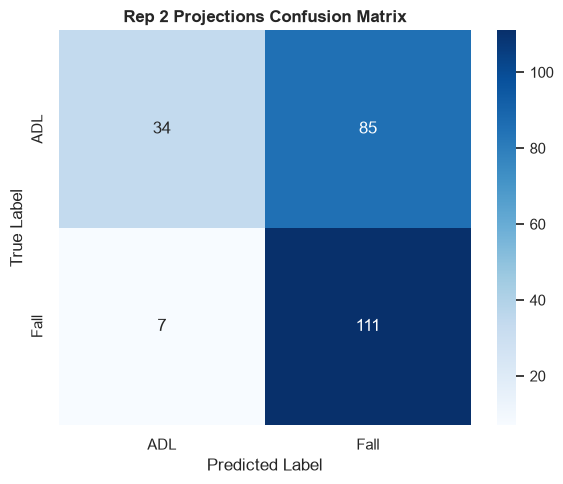

In [5]:
# Evaluate on Test Set
model.eval()
preds_list, probs_list, targets_list = [], [], []
with torch.no_grad():
    for bx, by in te_loader:
        bx = bx.to(device)
        out = model(bx)
        prob = torch.softmax(out, dim=1)[:, 1]
        preds_list.extend(out.argmax(dim=1).cpu().numpy())
        probs_list.extend(prob.cpu().numpy())
        targets_list.extend(by.numpy())

acc = accuracy_score(targets_list, preds_list)
auc = roc_auc_score(targets_list, probs_list)
cm = confusion_matrix(targets_list, preds_list)

print(f"--- Representation 2 (Orthogonal Projections ResNet-18) Test Results ---")
print(f"Test Accuracy: {acc*100:.2f}%")
print(f"ROC-AUC Score: {auc:.4f}")
print(classification_report(targets_list, preds_list, target_names=["Non-Fall ADL", "Fall"]))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["ADL", "Fall"], yticklabels=["ADL", "Fall"])
plt.title("Rep 2 Projections Confusion Matrix", fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()
